In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Bloco 7A.xlsx to Bloco 7A.xlsx


In [ ]:
import pandas as pd

def analisar_planilha(caminho_arquivo):
    # Carrega a planilha sem definir cabeçalho prévio
    xls = pd.ExcelFile(caminho_arquivo)
    print(f"=== ANÁLISE DO ARQUIVO: {caminho_arquivo} ===")
    print(f"Abas encontradas ({len(xls.sheet_names)}): {xls.sheet_names}\n")

    for aba in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=aba, header=None)

        # Descarta colunas que estejam 100% vazias
        df = df.dropna(how='all', axis=1)

        total_linhas, total_colunas = df.shape
        print(f"--- Aba: '{aba}' ---")
        print(f" Dimensão: {total_linhas} linhas x {total_colunas} colunas")
        print(" Detalhamento de cada coluna:")

        for col in df.columns:
            qtd_validos = df[col].count()
            pct_valido = (qtd_validos / total_linhas) * 100
            amostra = list(df[col].dropna().unique()[:3]) # pega até 3 exemplos
            print(f"   • Coluna {col}: {qtd_validos}/{total_linhas} preenchidos ({pct_valido:.1f}%) | Exemplos: {amostra}")

        print("\n PRIMEIRAS 5 LINHAS:")
        print(df.head(5))
        print("\n" + "="*50 + "\n")

# Executar a função passando o seu arquivo
analisar_planilha('Bloco 7A.xlsx')

=== ANÁLISE DO ARQUIVO: Bloco 7A.xlsx ===
Abas encontradas (2): ['Bloco 1', 'Bloco 2']

--- Aba: 'Bloco 1' ---
 Dimensão: 51 linhas x 9 colunas
 Detalhamento de cada coluna:
   • Coluna 0: 51/51 preenchidos (100.0%) | Exemplos: [np.int64(1001), np.int64(1002), np.int64(1003)]
   • Coluna 1: 38/51 preenchidos (74.5%) | Exemplos: ['padron', 'basico', 'pisobaixo']
   • Coluna 2: 38/51 preenchidos (74.5%) | Exemplos: [np.float64(3.0), np.float64(2.0)]
   • Coluna 3: 38/51 preenchidos (74.5%) | Exemplos: ['sim']
   • Coluna 4: 38/51 preenchidos (74.5%) | Exemplos: ['não', 'sim']
   • Coluna 5: 38/51 preenchidos (74.5%) | Exemplos: [np.float64(2014.0), np.float64(2015.0), np.float64(2016.0)]
   • Coluna 6: 3/51 preenchidos (5.9%) | Exemplos: ['2x2', 'dc']
   • Coluna 18: 1/51 preenchidos (2.0%) | Exemplos: ['maximo']
   • Coluna 19: 1/51 preenchidos (2.0%) | Exemplos: [np.float64(210.0)]

 PRIMEIRAS 5 LINHAS:
     0       1    2    3    4       5    6       18     19
0  1001  padron  3.0  si

In [ ]:
import pandas as pd

# 1. Definir os nomes das colunas de acordo com o seu domínio
colunas = [
    'ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado',
    'Ano', 'Observacao'
]

# 2. Função para carregar e formatar uma aba específica
def carregar_aba(nome_aba):
    df = pd.read_excel('Bloco 7A.xlsx', sheet_name=nome_aba, header=None)
    df = df.iloc[:, :7]  # Seleciona as colunas 0 a 6
    df.columns = colunas
    return df

# Carregar ambas as abas
df_b1 = carregar_aba('Bloco 1')
df_b2 = carregar_aba('Bloco 2')

# Unir os dois blocos em um único DataFrame
df_completo = pd.concat([df_b1, df_b2], ignore_index=True)

# 3. Remover linhas que são apenas IDs vazios (sem Categoria cadastrada)
df_limpo = df_completo.dropna(subset=['Categoria']).copy()

# 4. Ajustar os tipos de dados e preencher observações ausentes
df_limpo['Observacao'] = df_limpo['Observacao'].fillna('Nenhuma')
df_limpo['Portas'] = df_limpo['Portas'].astype(int)
df_limpo['Ano'] = df_limpo['Ano'].astype(int)

# 5. (Opcional) Se quiser criar uma versão onde as linhas incompletas são preenchidas com a moda:
df_imputado = df_completo.copy()
for col in ['Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano']:
    df_imputado[col] = df_imputado[col].fillna(df_imputado[col].mode()[0])

print("--- Resultado Final (Apenas Registros Válidos) ---")
print(df_limpo.head(10))
print(f"\nTotal de veículos válidos cadastrados: {len(df_limpo)}")

--- Resultado Final (Apenas Registros Válidos) ---
      ID Categoria  Portas Elevador Ar Condicionado   Ano Observacao
0   1001    padron       3      sim             não  2014    Nenhuma
1   1002    basico       3      sim             sim  2015    Nenhuma
2   1003    basico       2      sim             não  2014    Nenhuma
3   1004    basico       2      sim             não  2014    Nenhuma
4   1005    basico       2      sim             não  2014    Nenhuma
12  1013    basico       2      sim             não  2014    Nenhuma
13  1014    basico       3      sim             não  2014    Nenhuma
14  1015    basico       3      sim             não  2015    Nenhuma
15  1016    basico       2      sim             não  2014        2x2
16  1017    basico       3      sim             sim  2015    Nenhuma

Total de veículos válidos cadastrados: 189


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# 1. Carregar os dados
colunas = ['ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano', 'Observacao']
df_b1 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 1', header=None).iloc[:, :7]
df_b2 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 2', header=None).iloc[:, :7]

df_b1.columns = colunas
df_b2.columns = colunas

df = pd.concat([df_b1, df_b2], ignore_index=True)
df['Observacao'] = df['Observacao'].fillna('Nenhuma')

# -------------------------------------------------------------------------
# CENÁRIO 1: Moda / Maioria (Simples e Direto)
# -------------------------------------------------------------------------
df_moda = df.copy()
for col in ['Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano']:
    df_moda[col] = df_moda[col].fillna(df_moda[col].mode()[0])

df_moda['Portas'] = df_moda['Portas'].astype(int)
df_moda['Ano'] = df_moda['Ano'].astype(int)

# -------------------------------------------------------------------------
# CENÁRIO 2: Imputação por Vizinhos do Mesmos Bloco/Faixa de ID (KNN)
# -------------------------------------------------------------------------
df_knn = df.copy()

# Mapeia categorias de texto para números para permitir o cálculo de distância do KNN
cat_map = {val: i for i, val in enumerate(df_knn['Categoria'].dropna().unique())}
cat_map_inv = {i: val for val, i in cat_map.items()}

bin_map = {'sim': 1, 'não': 0}
bin_map_inv = {1: 'sim', 0: 'não'}

df_knn['Cat_num'] = df_knn['Categoria'].map(cat_map)
df_knn['Elev_num'] = df_knn['Elevador'].map(bin_map)
df_knn['Ar_num'] = df_knn['Ar Condicionado'].map(bin_map)

# Aplica KNN usando o ID como referência de vizinhança
imputer = KNNImputer(n_neighbors=3)
cols_knn = ['ID', 'Cat_num', 'Portas', 'Elev_num', 'Ar_num', 'Ano']
matriz_imputada = imputer.fit_transform(df_knn[cols_knn])

df_res_knn = pd.DataFrame(matriz_imputada, columns=cols_knn)

# Reverte os valores numéricos de volta para as categorias originais
df_knn['Categoria'] = df_res_knn['Cat_num'].round().map(cat_map_inv)
df_knn['Portas'] = df_res_knn['Portas'].round().astype(int)
df_knn['Elevador'] = df_res_knn['Elev_num'].round().map(bin_map_inv)
df_knn['Ar Condicionado'] = df_res_knn['Ar_num'].round().map(bin_map_inv)
df_knn['Ano'] = df_res_knn['Ano'].round().astype(int)

df_knn = df_knn[colunas] # Reorganiza as colunas originais

In [ ]:
# Arredonda a média para o inteiro mais próximo
media_portas = round(df['Portas'].mean())  # Resulta em 3
media_ano = round(df['Ano'].mean())        # Resulta em 2013

df['Portas'] = df['Portas'].fillna(media_portas).astype(int)
df['Ano'] = df['Ano'].fillna(media_ano).astype(int)

In [ ]:
# Após aplicar o KNNImputer:
df_knn['Portas'] = df_knn['Portas'].round().astype(int)
df_knn['Ano'] = df_knn['Ano'].round().astype(int)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# 1. Preparação da base
colunas = ['ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano', 'Observacao']
df_b1 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 1', header=None).iloc[:, :7]
df_b2 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 2', header=None).iloc[:, :7]
df_b1.columns = colunas
df_b2.columns = colunas

df = pd.concat([df_b1, df_b2], ignore_index=True)

# -------------------------------------------------------------------------
# CENÁRIO A: Média / Mediana (com arredondamento forçado)
# -------------------------------------------------------------------------
df_estat = df.copy()
df_estat['Portas'] = df_estat['Portas'].fillna(round(df_estat['Portas'].mean())).astype(int)
df_estat['Ano'] = df_estat['Ano'].fillna(round(df_estat['Ano'].median())).astype(int)

# -------------------------------------------------------------------------
# CENÁRIO B: Moda / Maioria (não quebra inteiros)
# -------------------------------------------------------------------------
df_moda = df.copy()
df_moda['Portas'] = df_moda['Portas'].fillna(df_moda['Portas'].mode()[0]).astype(int)
df_moda['Ano'] = df_moda['Ano'].fillna(df_moda['Ano'].mode()[0]).astype(int)

# -------------------------------------------------------------------------
# CENÁRIO C: KNN (arredondando a saída)
# -------------------------------------------------------------------------
df_knn = df.copy()
imputer = KNNImputer(n_neighbors=3)

# Imputa apenas as colunas numéricas usando o ID como referência
df_knn[['ID', 'Portas', 'Ano']] = imputer.fit_transform(df_knn[['ID', 'Portas', 'Ano']])

# Força a conversão para inteiros sem decimais
df_knn['Portas'] = df_knn['Portas'].round().astype(int)
df_knn['Ano'] = df_knn['Ano'].round().astype(int)

print("Exemplo do resultado KNN sem números quebrados:")
print(df_knn[['ID', 'Portas', 'Ano']].head(10))

Exemplo do resultado KNN sem números quebrados:
       ID  Portas   Ano
0  1001.0       3  2014
1  1002.0       3  2015
2  1003.0       2  2014
3  1004.0       2  2014
4  1005.0       2  2014
5  1006.0       2  2014
6  1007.0       2  2014
7  1008.0       2  2014
8  1009.0       2  2014
9  1010.0       3  2014


In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from google.colab import files

# 1. Definir a ordem oficial das colunas
colunas = ['ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano', 'Observacao']

# 2. Carregar e unificar as duas abas
df_b1 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 1', header=None).iloc[:, :7]
df_b2 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 2', header=None).iloc[:, :7]

df_b1.columns = colunas
df_b2.columns = colunas

df = pd.concat([df_b1, df_b2], ignore_index=True)

# 3. Preparar dados para a imputação inteligente por KNN
cat_map = {val: i for i, val in enumerate(df['Categoria'].dropna().unique())}
cat_map_inv = {i: val for val, i in cat_map.items()}

bin_map = {'sim': 1, 'não': 0}
bin_map_inv = {1: 'sim', 0: 'não'}

df['Cat_num'] = df['Categoria'].map(cat_map)
df['Elev_num'] = df['Elevador'].map(bin_map)
df['Ar_num'] = df['Ar Condicionado'].map(bin_map)

# 4. Imputar valores com base nos vizinhos de ID
cols_knn = ['ID', 'Cat_num', 'Portas', 'Elev_num', 'Ar_num', 'Ano']
imputer = KNNImputer(n_neighbors=3)
matriz_imputada = imputer.fit_transform(df[cols_knn])

df_res_knn = pd.DataFrame(matriz_imputada, columns=cols_knn)

# 5. Reverter mapeamentos e tratar números inteiros (sem decimais)
df_final = df.copy()
df_final['Categoria'] = df_res_knn['Cat_num'].round().map(cat_map_inv)
df_final['Portas'] = df_res_knn['Portas'].round().astype(int)
df_final['Elevador'] = df_res_knn['Elev_num'].round().map(bin_map_inv)
df_final['Ar Condicionado'] = df_res_knn['Ar_num'].round().map(bin_map_inv)
df_final['Ano'] = df_res_knn['Ano'].round().astype(int)
df_final['Observacao'] = df_final['Observacao'].fillna('Nenhuma')

# 6. Selecionar apenas as colunas oficiais
df_final = df_final[colunas]

# 7. Salvar e disparar o download no Google Colab
nome_arquivo = 'Bloco_7A_Tratado.xlsx'
df_final.to_excel(nome_arquivo, index=False)
files.download(nome_arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# O MESMO SCRIPT COM A BIBLIOTECA QUE LIDA COM AS CORES
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from google.colab import files

# 1. Mapeamento e unificação das abas
colunas = ['ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano', 'Observacao']

df_b1 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 1', header=None).iloc[:, :7]
df_b2 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 2', header=None).iloc[:, :7]
df_b1.columns = colunas
df_b2.columns = colunas

df = pd.concat([df_b1, df_b2], ignore_index=True)

# 2. Imputação inteligente dos dados (KNN)
cat_map = {val: i for i, val in enumerate(df['Categoria'].dropna().unique())}
cat_map_inv = {i: val for val, i in cat_map.items()}

bin_map = {'sim': 1, 'não': 0}
bin_map_inv = {1: 'sim', 0: 'não'}

df['Cat_num'] = df['Categoria'].map(cat_map)
df['Elev_num'] = df['Elevador'].map(bin_map)
df['Ar_num'] = df['Ar Condicionado'].map(bin_map)

cols_knn = ['ID', 'Cat_num', 'Portas', 'Elev_num', 'Ar_num', 'Ano']
imputer = KNNImputer(n_neighbors=3)
matriz_imputada = imputer.fit_transform(df[cols_knn])

df_res_knn = pd.DataFrame(matriz_imputada, columns=cols_knn)

df_final = df.copy()
df_final['Categoria'] = df_res_knn['Cat_num'].round().map(cat_map_inv)
df_final['Portas'] = df_res_knn['Portas'].round().astype(int)
df_final['Elevador'] = df_res_knn['Elev_num'].round().map(bin_map_inv)
df_final['Ar Condicionado'] = df_res_knn['Ar_num'].round().map(bin_map_inv)
df_final['Ano'] = df_res_knn['Ano'].round().astype(int)
df_final['Observacao'] = df_final['Observacao'].fillna('Nenhuma')

df_final = df_final[colunas]

# 3. Criação da planilha formatada com as cores originais
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Dados_Tratados"

# Configuração dos preenchimentos (Amarelo na Coluna A e Azul nas demais)
fill_col_a = PatternFill(start_color='FFFF00', end_color='FFFF00', fill_type='solid')
fill_col_outras = PatternFill(start_color='0070C0', end_color='0070C0', fill_type='solid')
fill_linha_a = PatternFill(start_color='FFFFE0', end_color='FFFFE0', fill_type='solid') # Amarelo claro nos IDs

font_header = Font(name='Calibri', size=11, bold=True, color='FFFFFF')
font_header_a = Font(name='Calibri', size=11, bold=True, color='000000')

# Escrever cabeçalhos estilizados
for col_num, col_name in enumerate(colunas, 1):
    cell = ws.cell(row=1, column=col_num, value=col_name)
    if col_num == 1:
        cell.fill = fill_col_a
        cell.font = font_header_a
    else:
        cell.fill = fill_col_outras
        cell.font = font_header
    cell.alignment = Alignment(horizontal='center', vertical='center')

# Escrever os dados mantendo o destaque visual da coluna A
for r_idx, row in df_final.iterrows():
    row_num = r_idx + 2
    for c_idx, val in enumerate(row, 1):
        cell = ws.cell(row=row_num, column=c_idx, value=val)
        cell.alignment = Alignment(horizontal='center' if c_idx != 2 else 'left')

        # Manter o fundo amarelo suave nas células da Coluna A (IDs)
        if c_idx == 1:
            cell.fill = fill_linha_a

# 4. Salvar e baixar o arquivo com a formatação completa
nome_arquivo = 'Bloco_7A_Tratado_Com_Cores.xlsx'
wb.save(nome_arquivo)
files.download(nome_arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

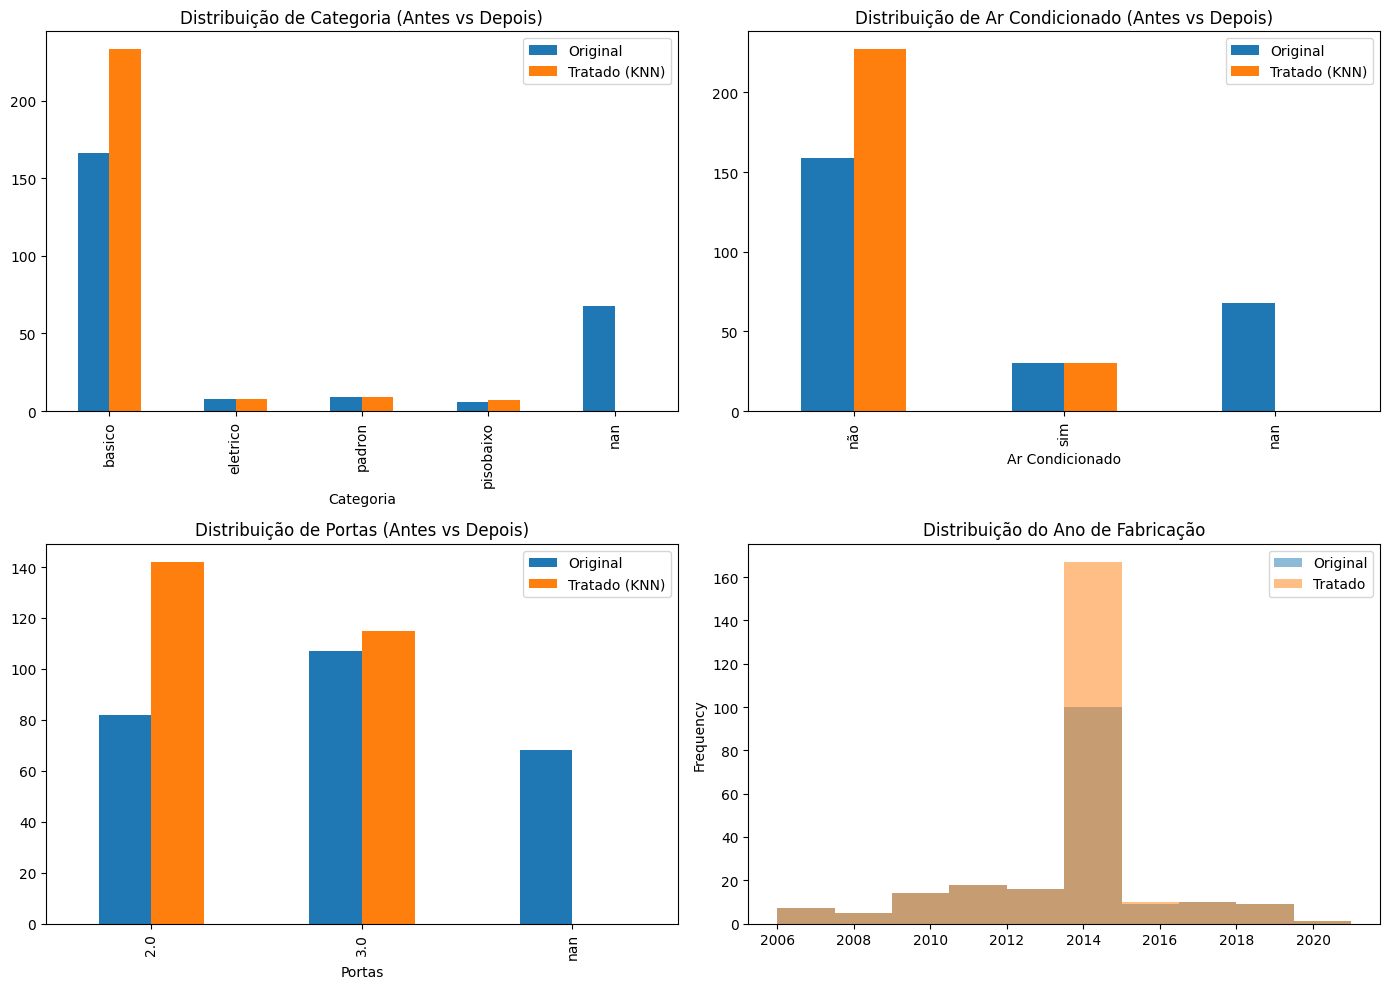

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# 1. Carregar dados originais
colunas = ['ID', 'Categoria', 'Portas', 'Elevador', 'Ar Condicionado', 'Ano', 'Observacao']
df_b1 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 1', header=None).iloc[:, :7]
df_b2 = pd.read_excel('Bloco 7A.xlsx', sheet_name='Bloco 2', header=None).iloc[:, :7]
df_b1.columns, df_b2.columns = colunas, colunas

df_orig = pd.concat([df_b1, df_b2], ignore_index=True)

# 2. Aplicar tratamento KNN
cat_map = {val: i for i, val in enumerate(df_orig['Categoria'].dropna().unique())}
cat_map_inv = {i: val for val, i in cat_map.items()}
bin_map, bin_map_inv = {'sim': 1, 'não': 0}, {1: 'sim', 0: 'não'}

df_trat = df_orig.copy()
df_trat['Cat_num'] = df_trat['Categoria'].map(cat_map)
df_trat['Elev_num'] = df_trat['Elevador'].map(bin_map)
df_trat['Ar_num'] = df_trat['Ar Condicionado'].map(bin_map)

cols_knn = ['ID', 'Cat_num', 'Portas', 'Elev_num', 'Ar_num', 'Ano']
imputer = KNNImputer(n_neighbors=3)
matriz_imputada = imputer.fit_transform(df_trat[cols_knn])

df_res_knn = pd.DataFrame(matriz_imputada, columns=cols_knn)

df_trat['Categoria'] = df_res_knn['Cat_num'].round().map(cat_map_inv)
df_trat['Portas'] = df_res_knn['Portas'].round().astype(int)
df_trat['Elevador'] = df_res_knn['Elev_num'].round().map(bin_map_inv)
df_trat['Ar Condicionado'] = df_res_knn['Ar_num'].round().map(bin_map_inv)
df_trat['Ano'] = df_res_knn['Ano'].round().astype(int)

# 3. Gerar gráficos comparativos (EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Categoria
pd.DataFrame({'Original': df_orig['Categoria'].value_counts(dropna=False),
              'Tratado (KNN)': df_trat['Categoria'].value_counts(dropna=False)}).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição de Categoria (Antes vs Depois)')

# Ar Condicionado
pd.DataFrame({'Original': df_orig['Ar Condicionado'].value_counts(dropna=False),
              'Tratado (KNN)': df_trat['Ar Condicionado'].value_counts(dropna=False)}).plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição de Ar Condicionado (Antes vs Depois)')

# Portas
pd.DataFrame({'Original': df_orig['Portas'].value_counts(dropna=False),
              'Tratado (KNN)': df_trat['Portas'].value_counts(dropna=False)}).plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Portas (Antes vs Depois)')

# Ano de Fabricação
df_orig['Ano'].plot(kind='hist', ax=axes[1, 1], alpha=0.5, label='Original', bins=10)
df_trat['Ano'].plot(kind='hist', ax=axes[1, 1], alpha=0.5, label='Tratado', bins=10)
axes[1, 1].set_title('Distribuição do Ano de Fabricação')
axes[1, 1].legend()

plt.tight_layout()
plt.show()